# Apply Signal Pipeline

In [14]:
from polymander.experiment_loader import LoadData
from polymander.signal_processing import *
from polymander.visualization import *

## Load raw data

In [15]:
# Load data
data = LoadData()
data.load_polymander_data(dir_name='../data/logs_polymander/static/FL/amp_0.5_freq_0.5', log_name='robot_data_log_2022-12-23_18_47_54')
data.load_force_plates_data(dir_name='../data/logs_force_plates/static/FL/amp_0.5_freq_0.5', log_name='exp2_amp_0.5_freq_0.5')

i = data.list_polymander[0]
j = data.list_force_plates[0]

------------------------ load data -------------------------
File robot_data_log_2022-12-23_18_47_54.csv in folder ../data/logs_polymander/static/FL/amp_0.5_freq_0.5 has been loaded
File exp2_amp_0.5_freq_0.5.txt in folder ../data/logs_force_plates/static/FL/amp_0.5_freq_0.5 has been loaded


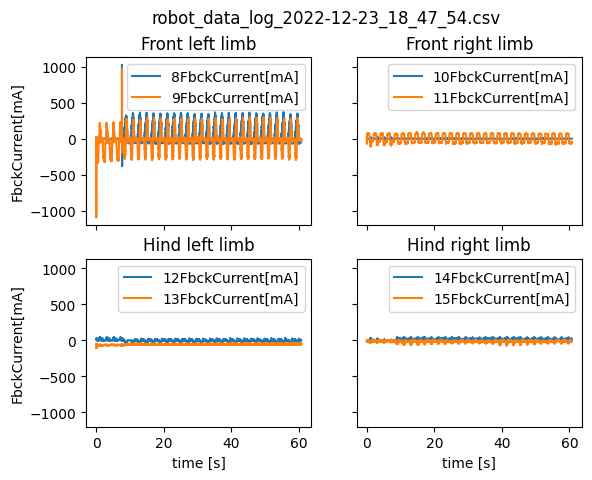

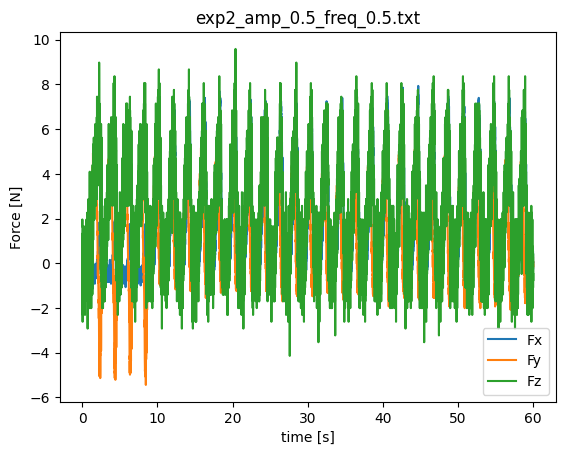

In [16]:
# Plot raw signals
i.plot_fbck_current(i.t_s, i.fbck_current_data)
j.plot_forces(j.t_s, j.Fxyz)

## Filtering

In [17]:
# 1) Filter signals
fbck_current_filtered = filtering_signal(i.fbck_current_data, 10)
Fxyz_filtered = filtering_signal(j.Fxyz, 20)

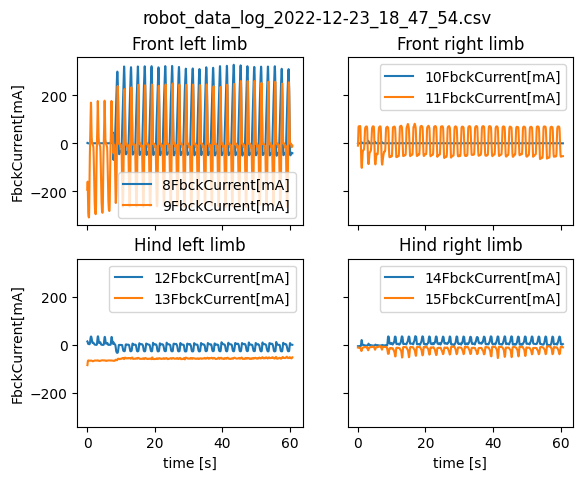

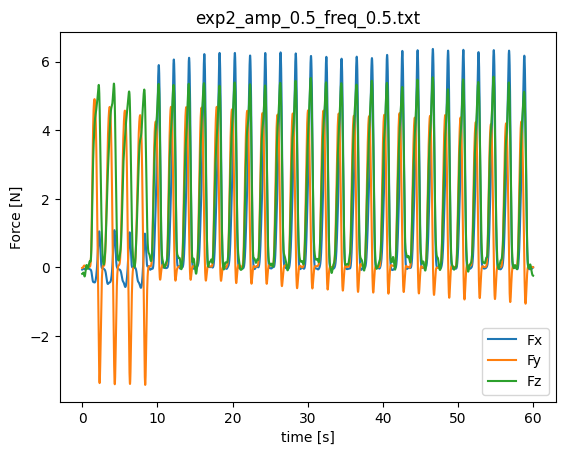

In [18]:
# Plot filtered signals
i.plot_fbck_current(i.t_s, fbck_current_filtered)
j.plot_forces(j.t_s, Fxyz_filtered)

## Plot filtered signals for the report (zoom in)

In [19]:
# Plot filtered signals for the report (zoom in)
indices = range(2000, 4000)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


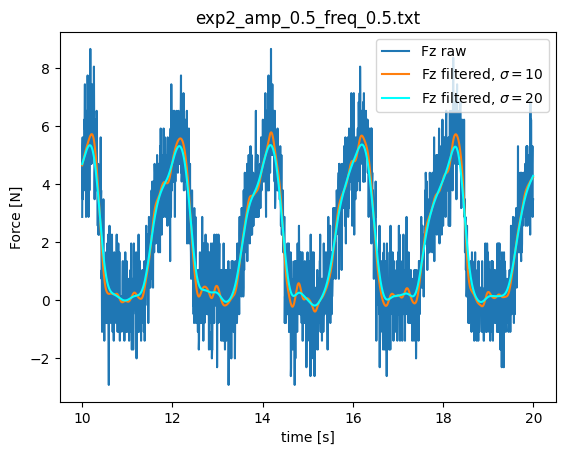

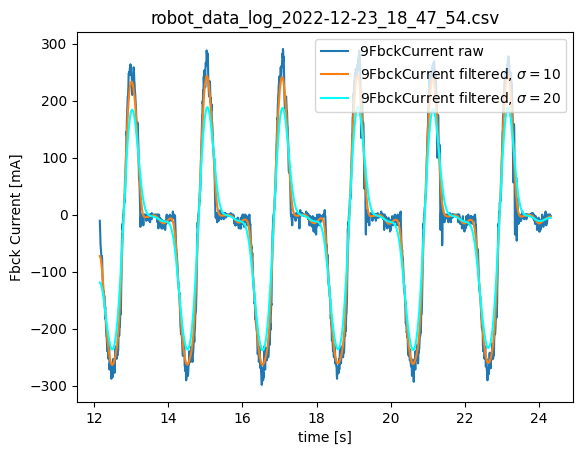

In [20]:
# Fz
fig, ax = plt.subplots()
ax.set_title(j.log_name)
ax.set(xlabel='time [s]', ylabel='Force [N]')
ax.plot(j.t_s[indices], j.Fxyz[indices, 2], label='Fz raw')
ax.plot(j.t_s[indices], filtering_signal(j.Fxyz, 10)[indices, 2], label='Fz filtered, $\sigma = 10$')
ax.plot(j.t_s[indices], filtering_signal(j.Fxyz, 20)[indices, 2], 'cyan', label='Fz filtered, $\sigma = 20$')
ax.legend()
plt.savefig('../results/figures/signal_processing/Fz_filtered.eps', format='eps')
plt.savefig('../results/figures/signal_processing/Fz_filtered.png', format='png')

# Fbck currents
fig, ax = plt.subplots()
ax.set_title(i.log_name)
ax.set(xlabel='time [s]', ylabel='Fbck Current [mA]')
ax.plot(i.t_s[indices], i.fbck_current_data[indices, 9], label=f'{i.fbck_current_headers[9][0:12]} raw')
ax.plot(i.t_s[indices], filtering_signal(i.fbck_current_data[indices, 9], 10), label=f'{i.fbck_current_headers[9][0:12]} filtered, $\sigma = 10$')
ax.plot(i.t_s[indices], filtering_signal(i.fbck_current_data[indices, 9], 20), 'cyan', label=f'{i.fbck_current_headers[9][0:12]} filtered, $\sigma = 20$')
ax.legend()
plt.savefig('../results/figures/signal_processing/current9_filtered.eps', format='eps')
plt.savefig('../results/figures/signal_processing/current9_filtered.png', format='png')

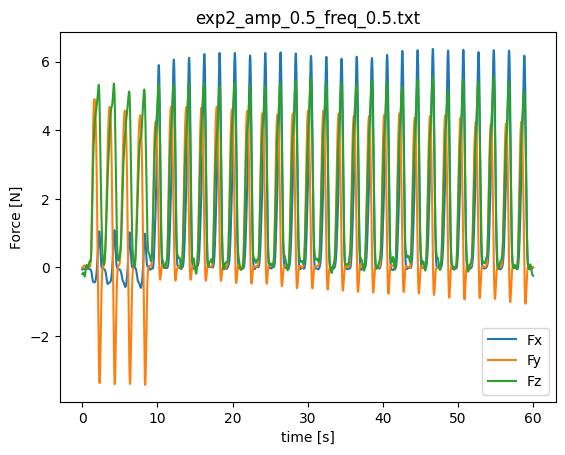

In [21]:
# 2) Resampling force plate signal based on polymander signal
t_s_fp_resampled, Fxyz_resampled = resample_signal(Fxyz_filtered, j.t_s, i.t_s)
j.plot_forces(t_s_fp_resampled, Fxyz_resampled)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


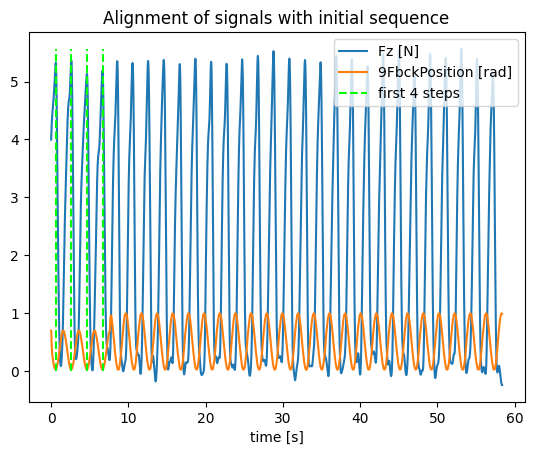

In [22]:
# 3) Manage delay between polymander and force plate
t_s_cut, fbck_position_cut, fbck_current_cut, Fxyz_cut = manage_delay_between_poly_and_fp(i.t_s, i.fbck_position_data,
                                                                                          fbck_current_filtered,
                                                                                          t_s_fp_resampled,
                                                                                          Fxyz_resampled, i.frequency)

# Plot aligned signals
plot_aligned_signals(t_s_cut, fbck_position_cut, Fxyz_cut, i.frequency)
plt.savefig('../results/figures/signal_processing/initial_sequence.eps', format='eps')
plt.savefig('../results/figures/signal_processing/initial_sequence.png', format='png')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


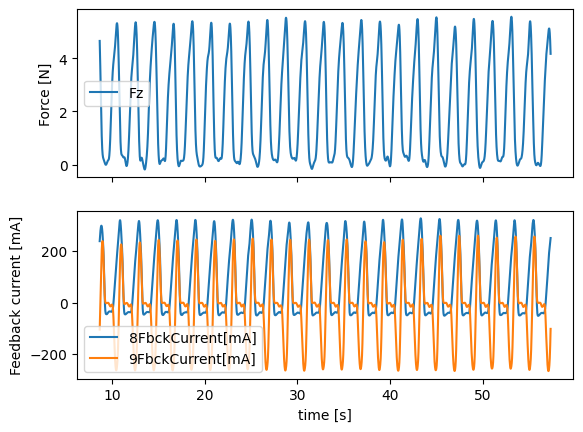

In [23]:
# 4) Remove initial sequence
t_s_final, fbck_position_final, fbck_current_final, Fxyz_final = remove_initial_sequence(t_s_cut, fbck_position_cut,
                                                                                         fbck_current_cut, Fxyz_cut,
                                                                                         i.frequency)

# Plot signals ready for the learning
fig, ax = plt.subplots(2, sharex=True)
ax[1].plot(t_s_final, fbck_current_final[:, 8:10], label=i.fbck_current_headers[8:10])
ax[1].set(xlabel='time [s]', ylabel='Feedback current [mA]')
ax[0].plot(t_s_final, Fxyz_final[:, 2], label=j.headers[3])
ax[0].set(xlabel='time [s]', ylabel='Force [N]')
for ax in ax.flat:
    ax.label_outer()
    ax.legend()
plt.savefig('../results/figures/signal_processing/crop_data.eps', format='eps')
plt.savefig('../results/figures/signal_processing/crop_data.png', format='png')

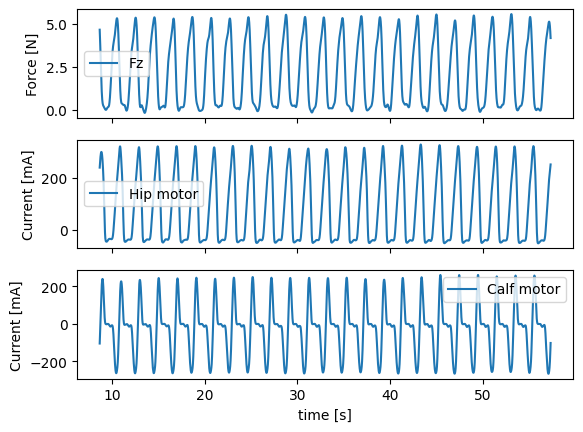

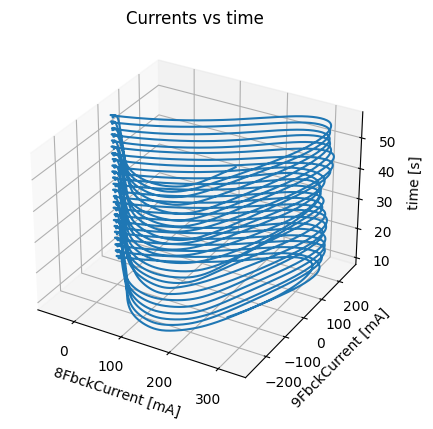

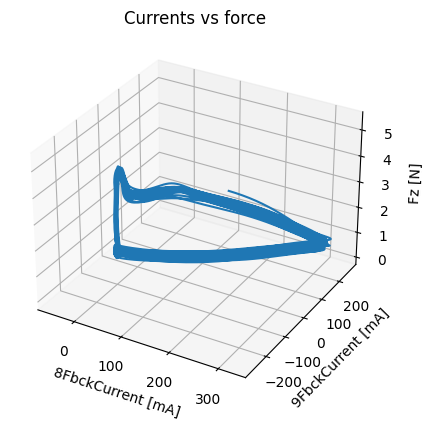

In [24]:
# Plot 3 subplots with current8 current9 and Fz
subplots_currents_and_forces(t_s_final, fbck_current_final[:, 8], fbck_current_final[:, 9], Fxyz_final[:, 2])

# Plot 3d currents vs time
plot_3d_curents_time(t_s_final, fbck_current_final[:, 8], fbck_current_final[:, 9])

# Plot 3d currents vs force
plot_3d_currents_force(Fxyz_final[:, 2], fbck_current_final[:, 8], fbck_current_final[:, 9])